## Question 2: Potato Disease Classification using CNN

You are provided with the **Potato Disease Dataset** from PlantVillage, which contains images of potato leaves classified into three categories:

- **Early_blight**: Leaves affected by early blight disease
- **Late_blight**: Leaves affected by late blight disease  
- **healthy**: Healthy potato leaves

Your objective is to build a **Convolutional Neural Network (CNN) from scratch** using PyTorch to classify potato leaves into these 3 disease categories.
Your work will be evaluated based on the completion of the following tasks:

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/q1-stage-3-2026")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mohammad2012191/q1-stage-3-2026


# Part 1: Load and Prepare Data (4 points)

**Tasks:**

- Create a custom Dataset class or use ImageFolder (if applicable)
- Create the training and testing datasets, and their DataLoaders
- Use RandomRotation(15) Augmentation on the training dataset + Reize the images to 32x32
- Display some sample images with their labels

> **First we will inspect the structure of the dataset, to decide how to build the custom Dataset class.**
> **Prefixing `!` before a command makes it run in the terminal directly. So we can run commands like `ls`, `cat` etc.**
> **Using `$` before a word, e.g. `$path` inserts the value of the variable `path` into the terminal command. Example given below.**

In [2]:
!apt-get -qq install tree
!tree -d $path

Selecting previously unselected package tree.
(Reading database ... 124463 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/kaggle/input/datasets/mohammad2012191/q1-stage-3-2026
└── PlantVillage
    ├── test
    │   ├── Potato___Early_blight
    │   ├── Potato___healthy
    │   └── Potato___Late_blight
    └── train
        ├── Potato___Early_blight
        ├── Potato___healthy
        └── Potato___Late_blight

9 directories


> **We can see that the structure is exactly the kind expected by `ImageFolder`. It takes an encloding folder, with subfolders for each class. So, we can create a dataset for the `train/` folder, and another for the `test/` folder.**
> 
> **Additionally, we are to apply two transforms on the dataset: Resize to 32x32, and apply `RandomRotation(15)`. As usual, the latter will only be applied on the training dataset.**

In [3]:
# Write your code here
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import Resize, Compose, RandomRotation, ToTensor
import os

train_transforms = Compose([Resize((32, 32)), ToTensor(),RandomRotation(15)])
test_transforms = Compose([Resize((32, 32)), ToTensor()])

train_ds = ImageFolder(os.path.join(path, "PlantVillage", 'train'), transform = train_transforms)
test_ds = ImageFolder(os.path.join(path, "PlantVillage", 'test'), transform = test_transforms)

batch_size = 64

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size)

Text(0.5, 0.98, 'Sample images with labels')

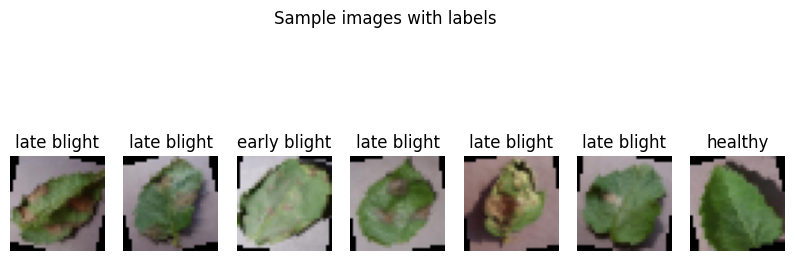

In [4]:
import matplotlib.pyplot as plt

num_images = 7

sample_images, labels = next(iter(train_loader))
sample_images, labels = sample_images[:num_images], labels[:num_images]

classes = ['early blight', 'late blight', 'healthy']

fig, ax = plt.subplots(1, num_images, figsize=(10, 4))
for i in range(num_images):
    ax[i].imshow(sample_images[i].permute(1, 2, 0))
    ax[i].axis('off')
    ax[i].set_title(classes[labels[i].item()])

fig.suptitle("Sample images with labels")

# Part 2: Build the CNN Model (3 points)

**Tasks:**

Build a CNN from scratch with the following specifications:

- Create a CNN model class with **5 convolutional layers**
- Bonus: Add **BatchNormalization** after each convolutional layer


In [5]:
# Write your code here
import torch.nn as nn

# Write your code here
import torch.nn as nn

class CNN5(nn.Module):
  def __init__(self):
    super(CNN5, self).__init__()
    self.fwdp = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding='same'), # 32 x 32 x 32
        nn.BatchNorm2d(32), # 
        nn.ReLU(),
        nn.MaxPool2d(2, 2), # 32 x 16 x 16
        nn.Conv2d(32, 64, 3, padding='same'), # 64 x 16 x 16
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),# 64 x 8 x 8
        nn.Conv2d(64, 128, 3, padding='same'), # 128 x 8 x 8
        nn.BatchNorm2d(128), # 
        nn.ReLU(),
        nn.MaxPool2d(2, 2),# 128 x 4 x 4
        nn.Conv2d(128, 128, 3, padding='same'),# 128 x 4 x 4
        nn.BatchNorm2d(128), # 
        nn.ReLU(),
        nn.MaxPool2d(2, 2),# 128 x 2 x 2
        nn.Conv2d(128, 256, 3, padding='same'), # 256 x 2 x 2
        nn.BatchNorm2d(256), # 
        nn.Flatten(),
        nn.Linear(256 * 2 * 2, 3) # 3 output classess
    )

  def forward(self, x):
    x = self.fwdp(x)
    return x

> **Here, we output raw logits in the CNN because we will be using `nn.CrossEntropyLoss()` to train our model, which expects raw logits.**

# Part 3: Training and Validation Functions

**Tasks:**

- Define the training loop function
- Define the validation loop function

In [6]:
# Write your code here
model = CNN5()
model

CNN5(
  (fwdp): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()

> **Same old training/validation functions. Copypasted from Labs of 2026 Stage 3.**

In [7]:
from tqdm import tqdm    # Shows progress bar
import torch
# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_loss += loss.item()

        # Track accuracy
        outputs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)  # Get class with highest probability
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()

            # Compute accuracy
            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)  # Get predicted class
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy


# Part 4: Training

**Tasks:**

- Set up device, model, loss function, and optimizer
- Train the model
- Plot the training and validation losses and training and validation accuracy

> **I already defined the model above (to see if output was as expected), so no need to do that again here. Only moving it to GPU.**

In [8]:
import torch.optim as optim

# comments are cuz copypasted from labs

# Initialize the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

100%|██████████| 27/27 [00:11<00:00,  2.41it/s]


Epoch 1/10: Train Loss=0.4503, Train Accuracy=82.57%, Val Loss=1.6213, Val Accuracy=46.40%


100%|██████████| 27/27 [00:03<00:00,  6.94it/s]


Epoch 2/10: Train Loss=0.2117, Train Accuracy=92.33%, Val Loss=0.3702, Val Accuracy=86.54%


100%|██████████| 27/27 [00:03<00:00,  7.16it/s]


...

Epoch 8/10: Train Loss=0.0494, Train Accuracy=98.55%, Val Loss=0.1031, Val Accuracy=96.75%


100%|██████████| 27/27 [00:04<00:00,  6.50it/s]


Epoch 9/10: Train Loss=0.0565, Train Accuracy=97.91%, Val Loss=0.1024, Val Accuracy=96.29%


100%|██████████| 27/27 [00:04<00:00,  6.02it/s]


Epoch 10/10: Train Loss=0.0511, Train Accuracy=98.14%, Val Loss=0.1002, Val Accuracy=96.52%


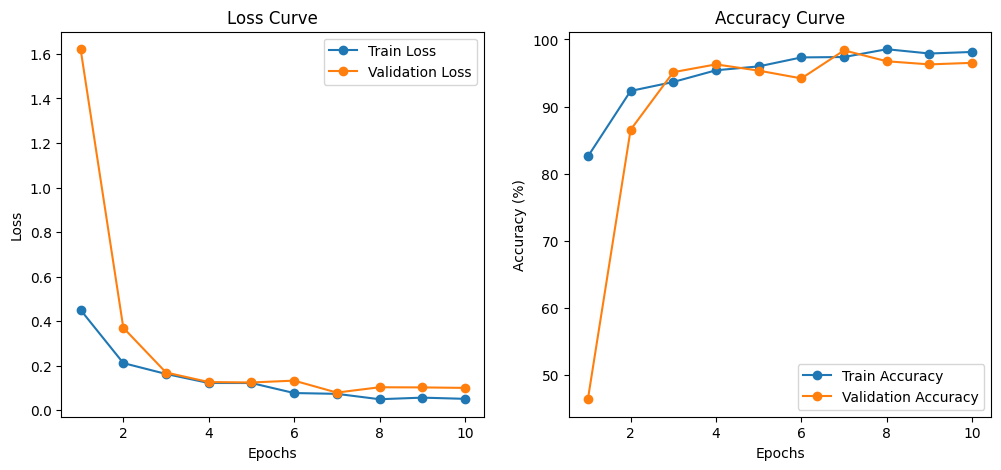

In [9]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

# Part 5: Bonus - Residual Connection

**Task:**

Now let's see if we can improve our model with a residual connection!

1. **Redefine the CNN model** but add a **residual (skip) connection** from the **2nd convolutional layer** to the **4th convolutional layer**
   - You can use either **summation** OR **concatenation** for the skip connection
   - Note: You might need to use pooling to match the size of the skip connection with the 3rd layer output before concatenation!

2. **Retrain** the model with the residual connection
3. Plot the training and validation losses and training and validation accuracy

> **At the bottom I've split the network into different "stages"/"modules", to let them connect again later with residual connections. Similar to U-Net architecture.**

In [10]:
# i added concat!!
# Write your code here
import torch.nn as nn

class CNN5_Skip(nn.Module):
  def __init__(self):
    super(CNN5_Skip, self).__init__()
    self.l1to2 = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding='same'), # 32 x 32 x 32 layer1 out
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2, 2), # 32 x 16 x 16
        nn.Conv2d(32, 64, 3, padding='same'), # 64 x 16 x 16 layer2 out
        nn.BatchNorm2d(64),
        nn.ReLU()
    )
    self.l3 = nn.Sequential(
        nn.MaxPool2d(2, 2),# 64 x 8 x 8
        nn.Conv2d(64, 128, 3, padding='same'), # 128 x 8 x 8
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2, 2) # 128 x 4 x 4  # layer3 out
    )
    self.l4onwards = nn.Sequential(
        nn.Conv2d(192, 128, 3, padding='same'),# 192 x 4 x 4 # changed channels cuz 128 from l3, 64 from l2 skipconn. rest same
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),# 128 x 2 x 2
        nn.Conv2d(128, 256, 3, padding='same'), # 256 x 2 x 2
        nn.BatchNorm2d(256),
        nn.Flatten(),
        nn.Linear(256 * 2 * 2, 256),
        nn.Linear(256, 3) # 3 output classess
    )
    self.pool = nn.MaxPool2d(4, 4) # will take l2out from 64 x 4 x 4 -> 64 x 4 x 4, matching with l3out which is 128 x 4 x 4
    # so now total channels for l4 input = 128 + 64 = 192
  def forward(self, x):
    layer2_out = self.l1to2(x)
    layer3_out = self.l3(layer2_out)
    layer2_skip = self.pool(layer2_out)
    x = self.l4onwards(torch.cat([layer2_skip, layer3_out], dim=1))
    return x

In [11]:
model = CNN5_Skip()
model

CNN5_Skip(
  (l1to2): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (l3): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (l4onwards): Sequential(
    (0): Conv2d(192, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1

In [12]:
import torch.optim as optim

# comments are cuz copypasted from labs

# Initialize the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

100%|██████████| 27/27 [00:04<00:00,  6.62it/s]


Epoch 1/10: Train Loss=0.4565, Train Accuracy=82.98%, Val Loss=1.4740, Val Accuracy=46.40%


100%|██████████| 27/27 [00:04<00:00,  6.46it/s]


Epoch 2/10: Train Loss=0.2308, Train Accuracy=91.87%, Val Loss=0.3699, Val Accuracy=85.85%


100%|██████████| 27/27 [00:04<00:00,  6.60it/s]


...

Epoch 8/10: Train Loss=0.0474, Train Accuracy=98.49%, Val Loss=0.0723, Val Accuracy=97.68%


100%|██████████| 27/27 [00:04<00:00,  6.71it/s]


Epoch 9/10: Train Loss=0.0384, Train Accuracy=98.66%, Val Loss=0.0678, Val Accuracy=97.45%


100%|██████████| 27/27 [00:03<00:00,  7.07it/s]


Epoch 10/10: Train Loss=0.0505, Train Accuracy=98.20%, Val Loss=0.1541, Val Accuracy=95.82%


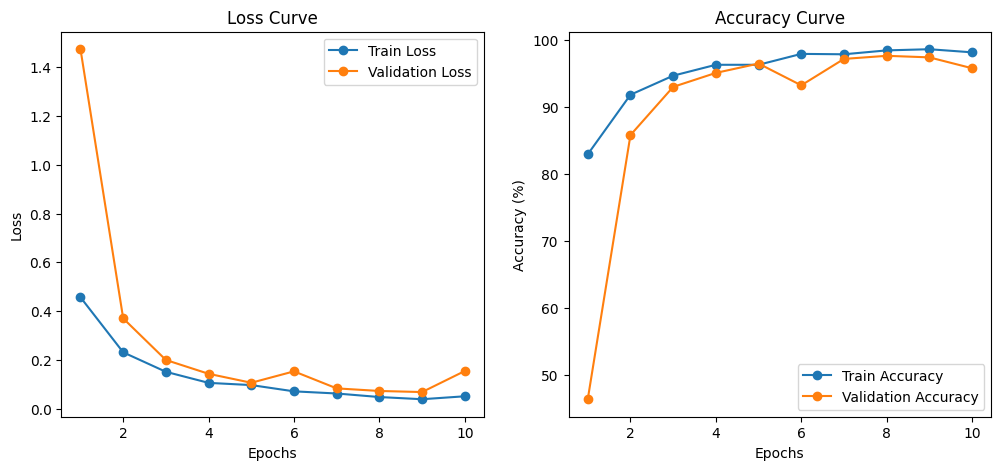

In [13]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

#reran now again for 10 epochs. see it also fits decent accuracy.
# with skip conns. bonus pls.